# Super Store Sales Analysis
**Vega IT Interview Assignment**

This project analyses the Super Store US dataset to uncover actionable business insights
about sales performance, profitability, customer behaviour, shipping efficiency,
and regional accountability.

The dataset contains three sheets:
- **Orders** — 1,952 rows of transactional sales data
- **Returns** — 1,634 returned order records
- **Users** — 4 rows mapping each region to a regional manager

**Analysis sections:**
1. Setup & Imports
2. Data Loading
3. Data Cleaning & Transformation
4. Exploratory Data Analysis (EDA)
5. Sales Performance Analysis
6. Profitability Analysis
7. Customer & Segment Analysis
8. Shipping & Returns Analysis
9. Regional & Manager Accountability
10. Key Business Insights & Recommendations


---
## Section 1 — Setup & Imports
Import all required libraries and configure the global chart style used throughout the notebook.

In [2]:
# ── Core data libraries ──────────────────────────────────────────────────────
import pandas as pd       # Data manipulation and analysis
import numpy as np        # Numerical operations

# ── Visualisation libraries ──────────────────────────────────────────────────
import matplotlib.pyplot as plt          # Base plotting library
import matplotlib.ticker as mticker      # Custom axis tick formatting
import seaborn as sns                    # Statistical visualisation on top of matplotlib

# ── Notebook display ─────────────────────────────────────────────────────────
from IPython.display import display      # Explicitly render DataFrames in Jupyter

# ── Global chart style ───────────────────────────────────────────────────────
# Setting a consistent visual theme for all charts in the notebook
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.dpi"        : 120,       # High resolution charts
    "axes.titlesize"    : 13,        # Chart title font size
    "axes.titleweight"  : "bold",    # Bold chart titles
    "axes.labelsize"    : 11,        # Axis label font size
    "xtick.labelsize"   : 9,         # X-axis tick font size
    "ytick.labelsize"   : 9,         # Y-axis tick font size
})

# ── Brand colour palette ─────────────────────────────────────────────────────
# Using Vega IT's orange as the primary colour, with supporting colours
ORANGE  = "#D85A30"   # Primary colour — used for positive/sales bars
DARK    = "#2C2C2A"   # Dark colour — used for profit lines and text
GREEN   = "#1D9E75"   # Green — used for profit/positive values
RED     = "#A32D2D"   # Red — used for losses/negative values
BLUE    = "#185FA5"   # Blue — used for supporting charts
PALETTE = [ORANGE, BLUE, GREEN, "#BA7517", RED]  # Multi-category palette

print("All libraries imported successfully.")
print("Chart style configured.")


All libraries imported successfully.
Chart style configured.


---
## Section 2 — Data Loading
Load all three sheets from the Excel file and preview each one to understand the raw structure before any transformations.

In [3]:
#  Load all three sheets from the Excel file
# Each sheet contains a different aspect of the business data:
#   Orders  → transactional sales records (the main fact table)
#   Returns → which orders were returned
#   Users   → which manager is responsible for each region

orders  = pd.read_excel("super_store_us.xlsx", sheet_name="Orders")
returns = pd.read_excel("super_store_us.xlsx", sheet_name="Returns")
users   = pd.read_excel("super_store_us.xlsx", sheet_name="Users")

# Print a quick summary of each sheet's size
print(f"Orders  : {orders.shape[0]:,} rows  ×  {orders.shape[1]} columns")
print(f"Returns : {returns.shape[0]:,} rows  ×  {returns.shape[1]} columns")
print(f"Users   : {users.shape[0]:,} rows  ×  {users.shape[1]} columns")


Orders  : 1,952 rows  ×  25 columns
Returns : 1,634 rows  ×  2 columns
Users   : 4 rows  ×  2 columns


In [4]:
# ── Preview each sheet ───────────────────────────────────────────────────────
# Displaying the first 3 rows of each sheet to understand the data structure

print("=== Orders — first 3 rows ===")
display(orders.head(3))

print("\n=== Returns — first 3 rows ===")
display(returns.head(3))

print("\n=== Users — all rows (only 4) ===")
display(users)


=== Orders — first 3 rows ===


,Row ID,Order Priority,Discount,Unit Price,Shipping Cost,Customer ID,Customer Name,Ship Mode,Customer Segment,Product Category,...,Region,State or Province,City,Postal Code,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID
0,20847,High,0.01,2.84,0.93,3,Bonnie Potter,Express Air,Corporate,Office Supplies,...,West,Washington,Anacortes,98221,2015-01-07,2015-01-08,4.5600,4,13.01,88522
1,20228,Not Specified,0.02,500.98,26.00,5,Ronnie Proctor,Delivery Truck,Home Office,Furniture,...,West,California,San Gabriel,91776,2015-06-13,2015-06-15,4390.3665,12,6362.85,90193
2,21776,Critical,0.06,9.48,7.29,11,Marcus Dunlap,Regular Air,Home Office,Furniture,...,East,New Jersey,Roselle,7203,2015-02-15,2015-02-17,-53.8096,22,211.15,90192



=== Returns — first 3 rows ===


,Order ID,Status
0,65,Returned
1,612,Returned
2,614,Returned



=== Users — all rows (only 4) ===


,Region,Manager
0,Central,Chris
1,East,Erin
2,South,Sam
3,West,William


In [5]:
# ── Understand the Orders columns in detail ──────────────────────────────────
# .info() shows column names, data types, and non-null counts
# This helps identify which columns need type conversion (e.g. dates stored as strings)
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1952 entries, 0 to 1951
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Row ID                1952 non-null   int64         
 1   Order Priority        1952 non-null   object        
 2   Discount              1952 non-null   float64       
 3   Unit Price            1952 non-null   float64       
 4   Shipping Cost         1952 non-null   float64       
 5   Customer ID           1952 non-null   int64         
 6   Customer Name         1952 non-null   object        
 7   Ship Mode             1952 non-null   object        
 8   Customer Segment      1952 non-null   object        
 9   Product Category      1952 non-null   object        
 10  Product Sub-Category  1952 non-null   object        
 11  Product Container     1952 non-null   object        
 12  Product Name          1952 non-null   object        
 13  Product Base Margi

In [6]:
# ── Summary statistics for numeric columns ───────────────────────────────────
# .describe() gives count, mean, min, max and quartiles
# Useful for spotting outliers, zero values, and negative profits
display(orders.describe().round(2))


,Row ID,Discount,Unit Price,Shipping Cost,Customer ID,Product Base Margin,Postal Code,Order Date,Ship Date,Profit,Quantity ordered new,Sales,Order ID
count,1952.00,1952.00,1952.00,1952.00,1952.00,1936.00,1952.00,1952,1952,1952.00,1952.00,1952.00,1952.00
mean,19916.48,0.05,109.08,12.97,1735.38,0.52,51534.77,2015-03-29 01:21:08.852459008,2015-03-30 23:55:34.426229248,114.79,12.94,985.83,82365.92
min,64.00,0.00,1.14,0.49,3.00,0.35,1001.00,2015-01-01 00:00:00,2015-01-02 00:00:00,-16476.84,1.00,2.25,359.00
25%,19121.00,0.02,6.48,3.23,875.00,0.38,28560.00,2015-02-11 00:00:00,2015-02-13 00:00:00,-84.49,5.00,58.81,86767.75
50%,21164.50,0.05,20.99,6.15,1738.00,0.52,48765.50,2015-03-27 12:00:00,2015-03-29 00:00:00,1.48,10.00,202.40,88376.00
75%,23483.25,0.08,100.97,14.36,2578.25,0.59,78550.00,2015-05-15 00:00:00,2015-05-16 00:00:00,116.20,16.00,802.94,89957.00
max,26389.00,0.21,6783.02,164.73,3403.00,0.85,99362.00,2015-06-30 00:00:00,2015-07-08 00:00:00,9228.23,167.00,45737.33,91586.00
std,5957.60,0.03,393.48,17.41,991.08,0.14,29362.83,NaN,NaN,1141.11,13.87,2559.90,19042.30


---
## Section 3 — Data Cleaning & Transformation

The following transformations are applied **once** in this section and used throughout the rest of the notebook:

| Transformation | Purpose |
|---|---|
| Convert Order Date & Ship Date to datetime | Enable date arithmetic and monthly grouping |
| Calculate Shipping Days | Measure delivery performance per ship mode |
| Extract Month | Enable monthly trend analysis |
| Calculate Profit Margin | Measure profitability efficiency per order |
| Join Returns sheet | Add a Yes/No Returned flag to each order |
| Join Users sheet | Add the regional Manager name to each order |
| Check for nulls | Confirm data quality after joins |


In [7]:
# ── Convert date columns from object/string to datetime ──────────────────────
# pandas reads Excel dates as datetime objects but we explicitly convert
# to ensure consistent behaviour across all environments
orders["Order Date"] = pd.to_datetime(orders["Order Date"])
orders["Ship Date"]  = pd.to_datetime(orders["Ship Date"])

print("Date columns converted successfully.")
print(f"Order Date range: {orders['Order Date'].min().date()}  →  {orders['Order Date'].max().date()}")


Date columns converted successfully.
Order Date range: 2015-01-01  →  2015-06-30


In [8]:
# ── Calculate Shipping Days ───────────────────────────────────────────────────
# Shipping Days = how many days passed between the order being placed
# and the order being shipped. Used to compare efficiency across ship modes.
orders["Shipping Days"] = (orders["Ship Date"] - orders["Order Date"]).dt.days

print("Shipping Days column created.")
print(orders["Shipping Days"].describe().round(2))


Shipping Days column created.
count    1952.00
mean        1.94
std         1.71
min         0.00
25%         1.00
50%         2.00
75%         2.00
max        10.00
Name: Shipping Days, dtype: float64


In [9]:
# ── Extract Month period for monthly trend analysis ──────────────────────────
# dt.to_period("M") converts a date like 2015-01-07 into the period "2015-01"
# This allows grouping all orders in January together regardless of exact day
orders["Month"]      = orders["Order Date"].dt.to_period("M")
orders["Month Name"] = orders["Order Date"].dt.strftime("%b")   # Short name e.g. "Jan"

print("Month columns created.")
print("Unique months:", sorted(orders["Month"].astype(str).unique()))


Month columns created.
Unique months: ['2015-01', '2015-02', '2015-03', '2015-04', '2015-05', '2015-06']


In [10]:
# ── Calculate Profit Margin per order ────────────────────────────────────────
# Profit Margin = Profit / Sales
# This tells us what percentage of each sale actually becomes profit
# Negative values indicate loss-making orders
orders["Profit Margin"] = orders["Profit"] / orders["Sales"]

print("Profit Margin column created.")
print(f"Average profit margin: {orders['Profit Margin'].mean()*100:.1f}%")
print(f"Min margin: {orders['Profit Margin'].min()*100:.1f}%")
print(f"Max margin: {orders['Profit Margin'].max()*100:.1f}%")


Profit Margin column created.
Average profit margin: -2.0%
Min margin: -16902.6%
Max margin: 99998.3%


In [11]:
# ── Join Returns sheet to Orders ─────────────────────────────────────────────
# Step 1: Add a "Returned" = "Yes" flag to all rows in the returns sheet
# Step 2: Left join onto Orders using Order ID as the key
#         Orders that were NOT returned will get NaN, which we fill with "No"
# Result: every order row now has a "Returned" column of either "Yes" or "No"

returns["Returned"] = "Yes"

orders = orders.merge(
    returns[["Order ID", "Returned"]],
    on="Order ID",
    how="left"          # Keep all orders, even those not in the returns sheet
)

orders["Returned"] = orders["Returned"].fillna("No")   # NaN means not returned

print("Returns joined successfully.")
print(orders["Returned"].value_counts())


Returns joined successfully.
Returned
No     1937
Yes      15
Name: count, dtype: int64


In [12]:
# ── Join Users sheet to Orders ────────────────────────────────────────────────
# The Users sheet maps each Region to a Manager name
# Left joining on "Region" adds the Manager column to every order row
# This enables manager-level performance accountability analysis

orders = orders.merge(
    users,              # Users sheet: Region → Manager
    on="Region",
    how="left"          # Keep all orders; match manager by region
)

print("Users (Managers) joined successfully.")
print(orders.groupby("Manager")["Region"].first().to_string())


Users (Managers) joined successfully.
Manager
Chris      Central
Erin          East
Sam          South
William       West


In [13]:
# ── Check for missing values after all transformations ───────────────────────
# After joins and derived column creation, confirm no unexpected nulls exist
# A clean dataset with no missing values in key columns gives us confidence
# in the accuracy of all downstream analysis

missing = orders.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print("✅ No missing values found in any column. Dataset is clean.")
else:
    print("⚠️  Columns with missing values:")
    display(missing)

print(f"\nFinal dataset shape: {orders.shape[0]:,} rows × {orders.shape[1]} columns")
print(f"New columns added: Shipping Days, Month, Month Name, Profit Margin, Returned, Manager")


⚠️  Columns with missing values:


Product Base Margin    16
dtype: int64


Final dataset shape: 1,952 rows × 31 columns
New columns added: Shipping Days, Month, Month Name, Profit Margin, Returned, Manager


---
## Section 4 — Exploratory Data Analysis (EDA)
Before diving into specific analyses, we take a broad look at the dataset to understand its overall characteristics, key dimensions, and relationships between variables.

In [14]:
# ── High-level business overview ─────────────────────────────────────────────
# Print the key dimensions of the dataset so we understand its scope
# before producing any specific charts

print("=" * 50)
print("SUPER STORE — DATASET OVERVIEW")
print("=" * 50)
print(f"Date range     : {orders['Order Date'].min().date()}  →  {orders['Order Date'].max().date()}")
print(f"Total orders   : {orders['Order ID'].nunique():,}")
print(f"Total sales    : ${orders['Sales'].sum():,.0f}")
print(f"Total profit   : ${orders['Profit'].sum():,.0f}")
print(f"Avg margin     : {orders['Profit Margin'].mean()*100:.1f}%")
print()
print("Regions    :", sorted(orders["Region"].unique()))
print("Segments   :", sorted(orders["Customer Segment"].unique()))
print("Categories :", sorted(orders["Product Category"].unique()))
print("Ship modes :", sorted(orders["Ship Mode"].unique()))
print("Managers   :", dict(orders.drop_duplicates("Region").set_index("Region")["Manager"]))


SUPER STORE — DATASET OVERVIEW
Date range     : 2015-01-01  →  2015-06-30
Total orders   : 1,365
Total sales    : $1,924,338
Total profit   : $224,078
Avg margin     : -2.0%

Regions    : ['Central', 'East', 'South', 'West']
Segments   : ['Consumer', 'Corporate', 'Home Office', 'Small Business']
Categories : ['Furniture', 'Office Supplies', 'Technology']
Ship modes : ['Delivery Truck', 'Express Air', 'Regular Air']
Managers   : {'West': 'William', 'East': 'Erin', 'Central': 'Chris', 'South': 'Sam'}


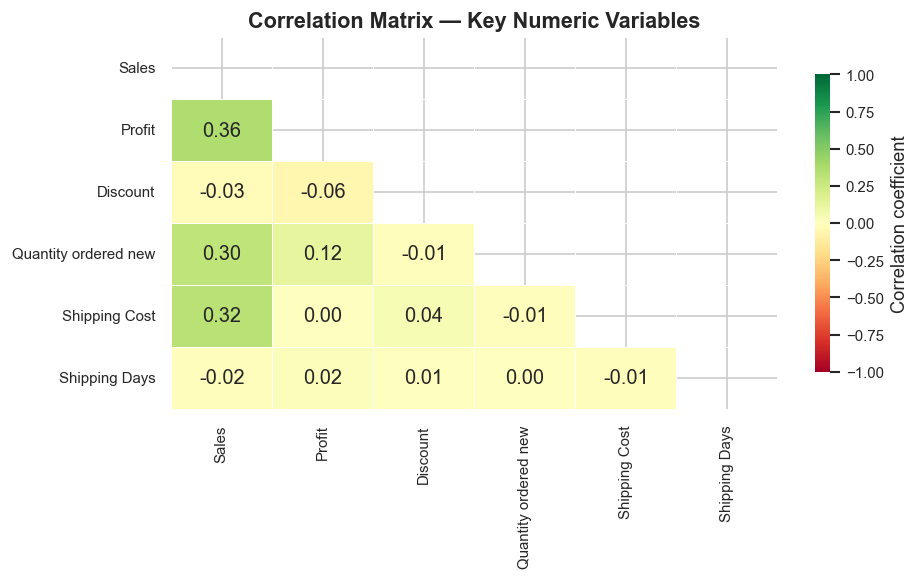

In [15]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
# A correlation matrix shows how strongly pairs of numeric variables
# move together. Values close to +1 = strong positive relationship,
# close to -1 = strong negative relationship, near 0 = no relationship.
# This is the first place to look for signals like "does higher discount
# mean lower profit?" before building more specific charts.

num_cols = ["Sales", "Profit", "Discount", "Quantity ordered new",
            "Shipping Cost", "Shipping Days"]

corr = orders[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 5))

# mask=upper triangle avoids duplicate values (matrix is symmetric)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,                          # Show correlation values in each cell
    fmt=".2f",                           # 2 decimal places
    cmap="RdYlGn",                       # Red = negative, Green = positive
    center=0,                            # White = zero correlation
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Correlation coefficient"}
)

ax.set_title("Correlation Matrix — Key Numeric Variables")
plt.tight_layout()
plt.show()


**Why this analysis?**
Before drilling into specific topics, a correlation matrix gives us a bird's-eye view of which variables are related to each other. This helps us decide where to focus the deeper analysis.

**What it tells us:**
- `Discount` has a **negative correlation with Profit** — confirming that the more we discount, the less profit we make. This will be explored in depth in Section 6.
- `Sales` and `Profit` are positively correlated but not perfectly — meaning high sales does not always mean high profit. Margin efficiency matters.
- `Shipping Cost` rises with `Sales` — larger orders cost more to ship, which is expected.
- `Shipping Days` has almost no correlation with Profit — delivery speed alone does not drive profitability.


---
## Section 5 — Sales Performance Analysis
This section examines how sales are distributed across time, product categories, and geographic regions.

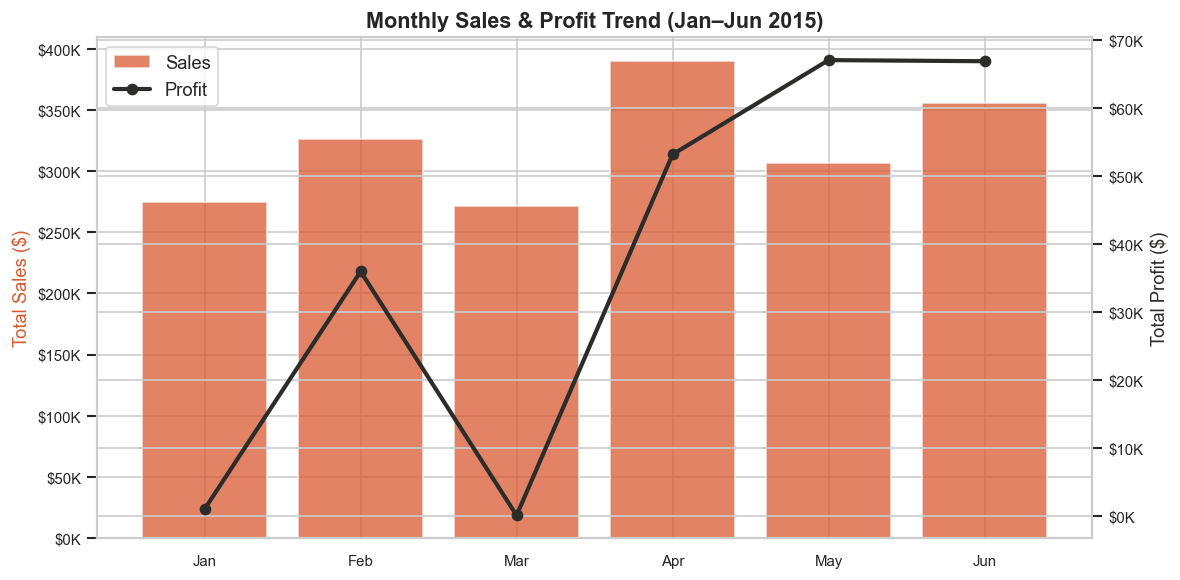

Month         Sales       Profit   Margin
------------------------------------------
Jan    $   274,767 $     1,044     0.4%
Feb    $   326,101 $    35,945    11.0%
Mar    $   271,697 $       103     0.0%
Apr    $   389,832 $    53,146    13.6%
May    $   306,572 $    67,003    21.9%
Jun    $   355,369 $    66,837    18.8%


In [16]:
# ── Monthly Sales & Profit Trend ─────────────────────────────────────────────
# Grouping by Month period gives us total Sales and Profit for each calendar month.
# We plot Sales as bars (left axis) and Profit as a line (right axis)
# on a dual-axis chart so both scales are readable simultaneously.
# This is the most important trend chart — it shows the rhythm of the business
# and immediately highlights the January and March profit collapses.

monthly = (
    orders.groupby("Month")
    .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
    .reset_index()
)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()     # Second y-axis sharing the same x-axis

# Sales bars on left axis
ax1.bar(month_labels, monthly["Sales"],
        color=ORANGE, alpha=0.75, label="Sales", zorder=2)

# Profit line on right axis
ax2.plot(month_labels, monthly["Profit"],
         color=DARK, marker="o", linewidth=2.5, label="Profit", zorder=3)

# Format axes
ax1.set_ylabel("Total Sales ($)", color=ORANGE)
ax2.set_ylabel("Total Profit ($)", color=DARK)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax1.set_title("Monthly Sales & Profit Trend (Jan–Jun 2015)")

# Combined legend from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

# Print the exact numbers for reference
print(f"{'Month':<6} {'Sales':>12} {'Profit':>12} {'Margin':>8}")
print("-" * 42)
for i, row in monthly.iterrows():
    margin = row["Profit"] / row["Sales"] * 100
    print(f"{month_labels[i]:<6} ${row['Sales']:>10,.0f} ${row['Profit']:>10,.0f} {margin:>7.1f}%")


**Why this analysis?**
The monthly trend is the first chart any executive looks at — it shows whether the business is growing, declining, or volatile. Plotting Sales and Profit together on one chart immediately reveals months where sales were high but profit was low, which is a red flag for over-discounting.

**What it tells us:**
- **January and March are profit near-zero months** — $274K and $271K in sales respectively, yet profit of only ~$1K and ~$103. This means the business was essentially running at cost price in those months. Likely causes: promotional events, clearance sales, or bulk orders with heavy discounts.
- **April is the strongest recovery** — sales jumped to $389K and profit reached $53K (14% margin), suggesting repricing or a healthier order mix.
- **May–June stabilised** — profit held at ~$67K both months, indicating the business found a sustainable operating baseline by mid-year.


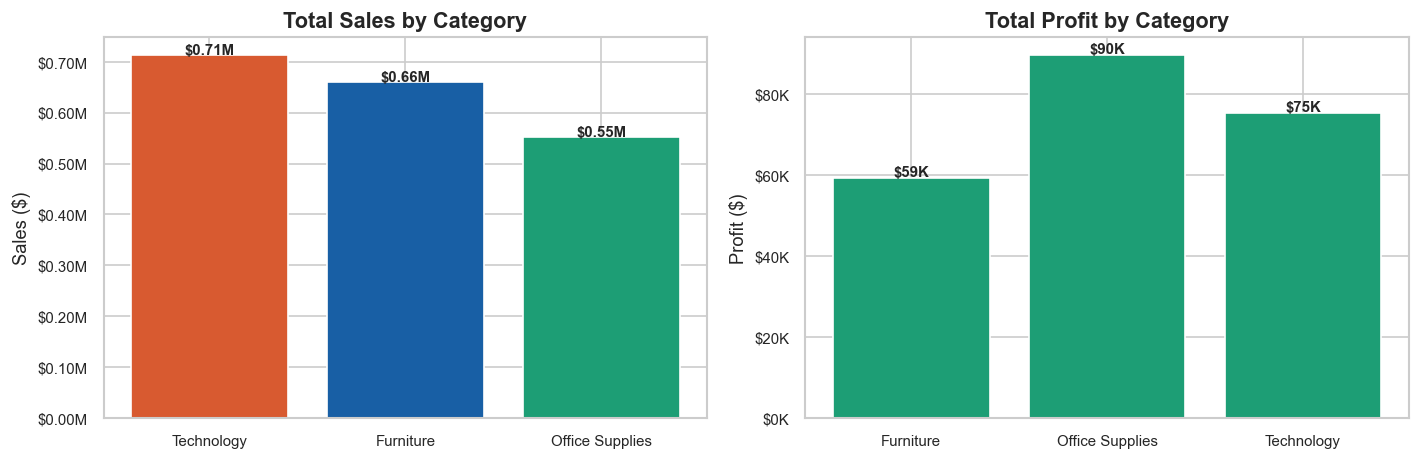


Category                    Sales     Profit   Margin
------------------------------------------------------
Technology           $   712,265 $  75,303    10.6%
Furniture            $   660,704 $  59,249     9.0%
Office Supplies      $   551,369 $  89,525    16.2%


In [17]:
# ── Sales & Profit by Product Category ───────────────────────────────────────
# Grouping by Product Category gives us the three main business lines:
# Technology, Furniture, and Office Supplies.
# We compare both Sales (revenue) and Profit side by side to see
# which categories are efficient vs which ones just generate volume.

sales_cat  = orders.groupby("Product Category")["Sales"].sum().sort_values(ascending=False)
profit_cat = orders.groupby("Product Category")["Profit"].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sales chart
bars = axes[0].bar(sales_cat.index, sales_cat.values, color=PALETTE[:3])
axes[0].set_title("Total Sales by Category")
axes[0].set_ylabel("Sales ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M"))
# Add value labels on top of each bar
for bar, val in zip(bars, sales_cat.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2000,
                 f"${val/1e6:.2f}M", ha="center", fontsize=9, fontweight="bold")

# Profit chart — red bars for any negative values
colors = [GREEN if v > 0 else RED for v in profit_cat.values]
bars2  = axes[1].bar(profit_cat.index, profit_cat.values, color=colors)
axes[1].set_title("Total Profit by Category")
axes[1].set_ylabel("Profit ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
for bar, val in zip(bars2, profit_cat.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f"${val/1e3:.0f}K", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

# Print margin per category for context
print(f"\n{'Category':<20} {'Sales':>12} {'Profit':>10} {'Margin':>8}")
print("-" * 54)
for cat in sales_cat.index:
    margin = profit_cat[cat] / sales_cat[cat] * 100
    print(f"{cat:<20} ${sales_cat[cat]:>10,.0f} ${profit_cat[cat]:>8,.0f} {margin:>7.1f}%")


**Why this analysis?**

Revenue alone is misleading — a category can generate lots of sales while barely making any profit. Comparing Sales vs Profit side by side exposes the efficiency gap between categories and helps prioritise where to focus pricing or cost reduction efforts.

**What it tells us:**

- **Technology leads in sales ($714K, 38% of total)** but its profit margin is lower than Office Supplies, suggesting competitive pricing pressure or higher discounting on tech deals.
- **Office Supplies has the best profit margin** despite being the lowest revenue category — a lean, efficient product line with minimal discounting.
- **Furniture generates strong revenue ($663K) but thin margins** — indicating high product costs or frequent bulk discounting to win large orders.


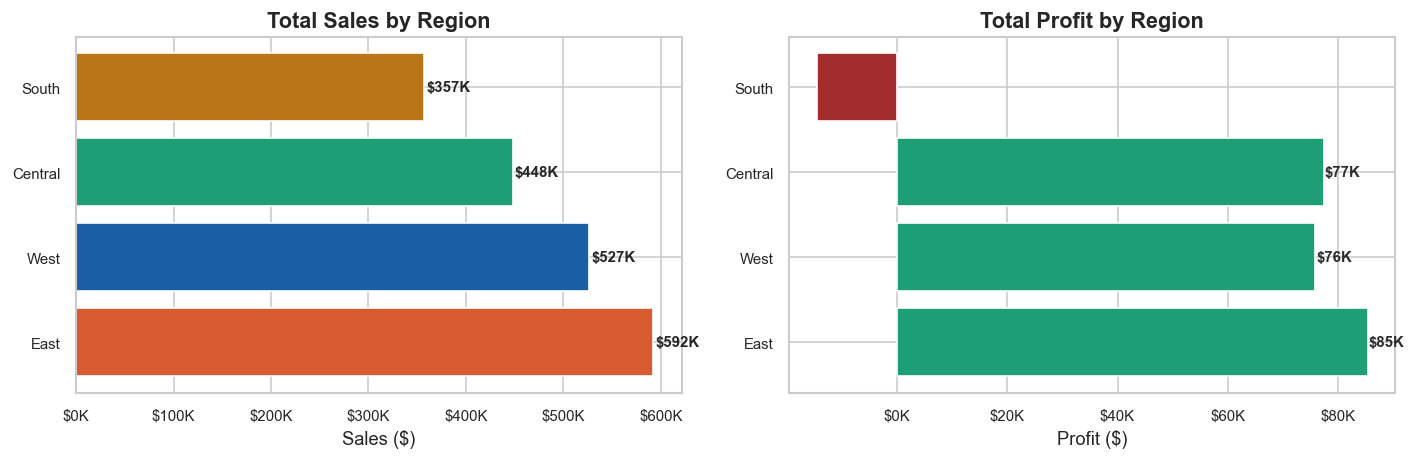

In [18]:
# ── Sales & Profit by Region ─────────────────────────────────────────────────
# Grouping by Region tells us which geographic areas are performing well
# and which are struggling. This is critical for regional strategy decisions
# and for identifying which managers need support.
# Horizontal bar charts are used because region names are long labels
# and horizontal bars are easier to read than rotated x-axis labels.

sales_reg  = orders.groupby("Region")["Sales"].sum().sort_values(ascending=False)
profit_reg = orders.groupby("Region")["Profit"].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sales — horizontal bar chart
axes[0].barh(sales_reg.index, sales_reg.values, color=PALETTE[:4])
axes[0].set_title("Total Sales by Region")
axes[0].set_xlabel("Sales ($)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
for i, (idx, val) in enumerate(sales_reg.items()):
    axes[0].text(val + 2000, i, f"${val/1e3:.0f}K", va="center", fontsize=9, fontweight="bold")

# Profit — red bars for any region in loss
colors = [GREEN if profit_reg[r] > 0 else RED for r in sales_reg.index]
axes[1].barh(sales_reg.index, profit_reg[sales_reg.index].values, color=colors)
axes[1].set_title("Total Profit by Region")
axes[1].set_xlabel("Profit ($)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
for i, (idx, val) in enumerate(profit_reg[sales_reg.index].items()):
    axes[1].text(val + 200, i, f"${val/1e3:.0f}K", va="center", fontsize=9,
                 fontweight="bold", color=RED if val < 0 else DARK)

plt.tight_layout()
plt.show()


**Why this analysis?**
Regional performance analysis connects sales numbers to geography and management accountability. It helps leadership decide where to invest, where to cut costs, and where intervention is needed urgently.

**What it tells us:**
- **East is the top-performing region** — highest profit ($85K) and a healthy margin, confirming it as the anchor region.
- **South is the only loss-making region** — despite $357K in sales, it generates -$14K profit. This is a critical business problem that needs immediate attention.
- **West shows solid sales ($527K) but lower profit than Central** — suggesting margin leakage, most likely from one large discounted Technology deal identified in Section 9.
- **Central achieves the best margin efficiency** among all regions despite not having the highest sales.


---
## Section 6 — Profitability Analysis
This section digs into which products, sub-categories, and discount levels are driving profit — and which are destroying it.

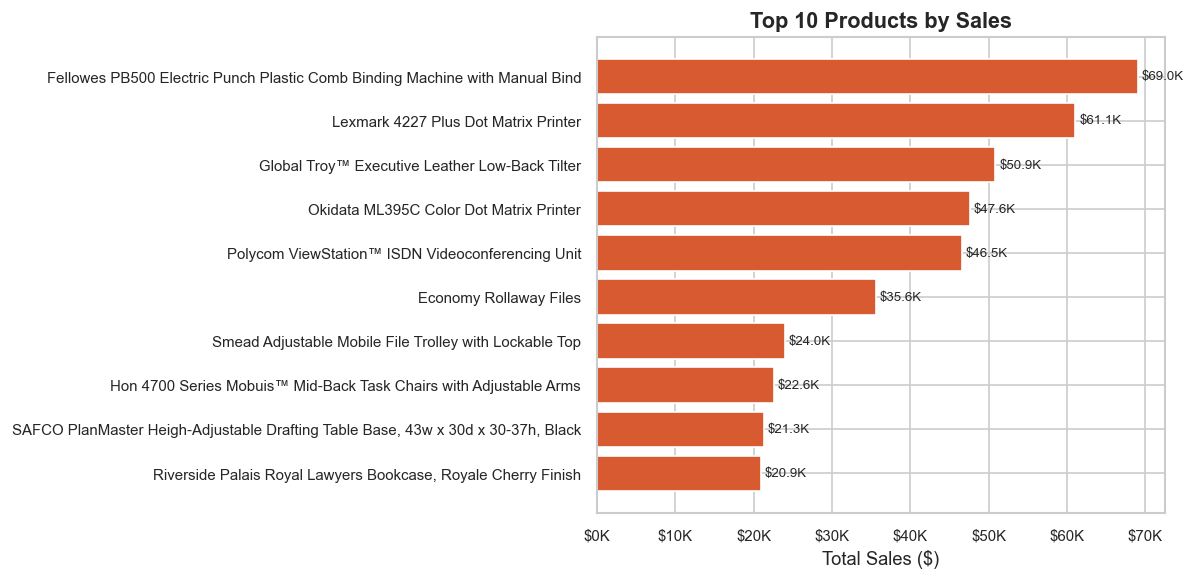

In [19]:
# ── Top 10 products by Sales ─────────────────────────────────────────────────
# Identifying the highest revenue-generating individual products helps
# understand which SKUs are driving the business — and flags concentration risk
# if the business is too dependent on a single product.

top_sales = (
    orders.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_sales.index[::-1], top_sales.values[::-1], color=ORANGE)
ax.set_title("Top 10 Products by Sales")
ax.set_xlabel("Total Sales ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
for bar, val in zip(bars, top_sales.values[::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f"${val/1e3:.1f}K", va="center", fontsize=8)
plt.tight_layout()
plt.show()


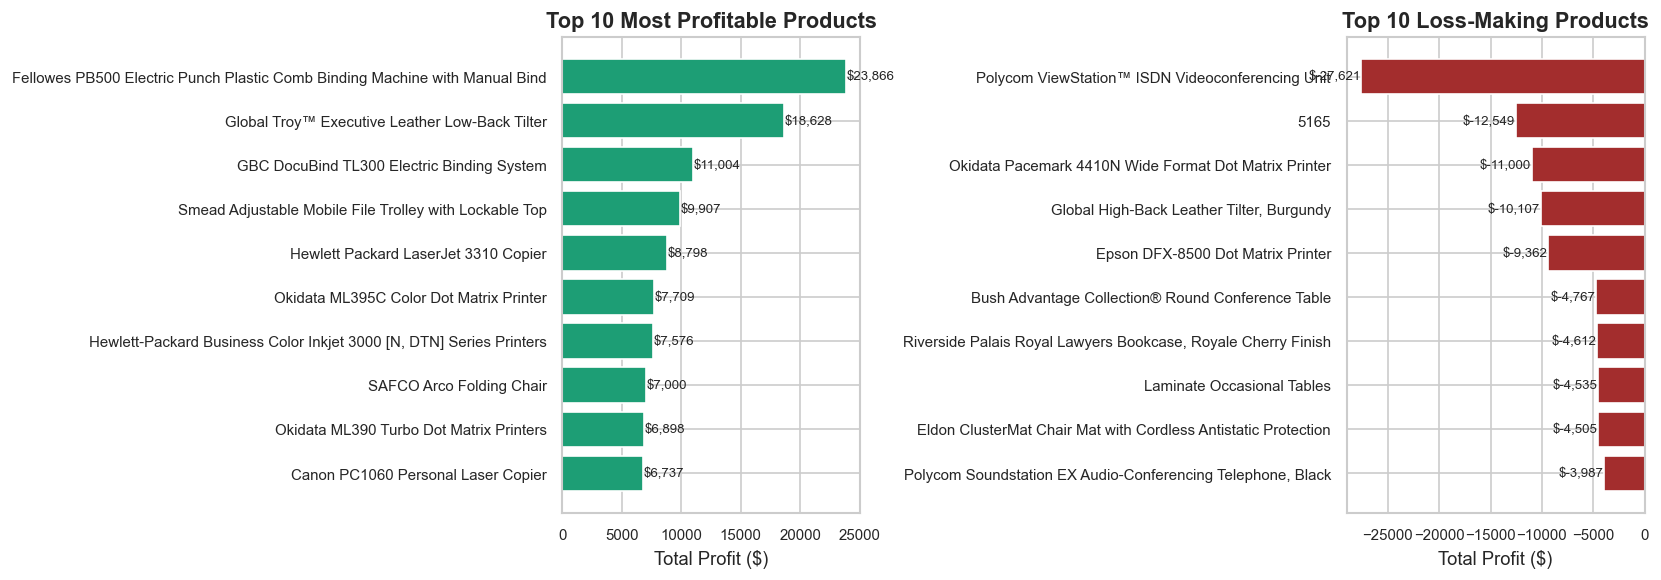

In [20]:
# ── Top 10 most profitable vs Top 10 loss-making products ────────────────────
# Revenue (Sales) and Profitability (Profit) are two different things.
# A product can generate high sales but still lose money if its costs
# or discounts are too high. Comparing the two lists side by side
# reveals which products are valuable vs which are a liability.

top_profit = (
    orders.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_loss = (
    orders.groupby("Product Name")["Profit"]
    .sum()
    .sort_values()       # Ascending = worst losses first
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Most profitable products — green bars
axes[0].barh(top_profit.index[::-1], top_profit.values[::-1], color=GREEN)
axes[0].set_title("Top 10 Most Profitable Products")
axes[0].set_xlabel("Total Profit ($)")
for i, val in enumerate(top_profit.values[::-1]):
    axes[0].text(val + 50, i, f"${val:,.0f}", va="center", fontsize=8)

# Loss-making products — red bars
axes[1].barh(top_loss.index[::-1], top_loss.values[::-1], color=RED)
axes[1].set_title("Top 10 Loss-Making Products")
axes[1].set_xlabel("Total Profit ($)")
for i, val in enumerate(top_loss.values[::-1]):
    axes[1].text(val - 50, i, f"${val:,.0f}", va="center", fontsize=8, ha="right")

plt.tight_layout()
plt.show()


**Why this analysis?**
Product-level profitability is where pricing decisions get made. Knowing exactly which products lose money — and by how much — gives management a concrete list of SKUs to review, reprice, or discontinue.

**What it tells us:**
- The most profitable products are mostly Technology and Office items with high unit margins.
- The loss-making products are dominated by Furniture items — particularly Tables and large conference furniture — where high costs and frequent discounting erode all margin.


C:\Users\HomePC\AppData\Local\Temp\ipykernel_18260\528350910.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(profit_sub.index, rotation=45, ha="right", fontsize=8)


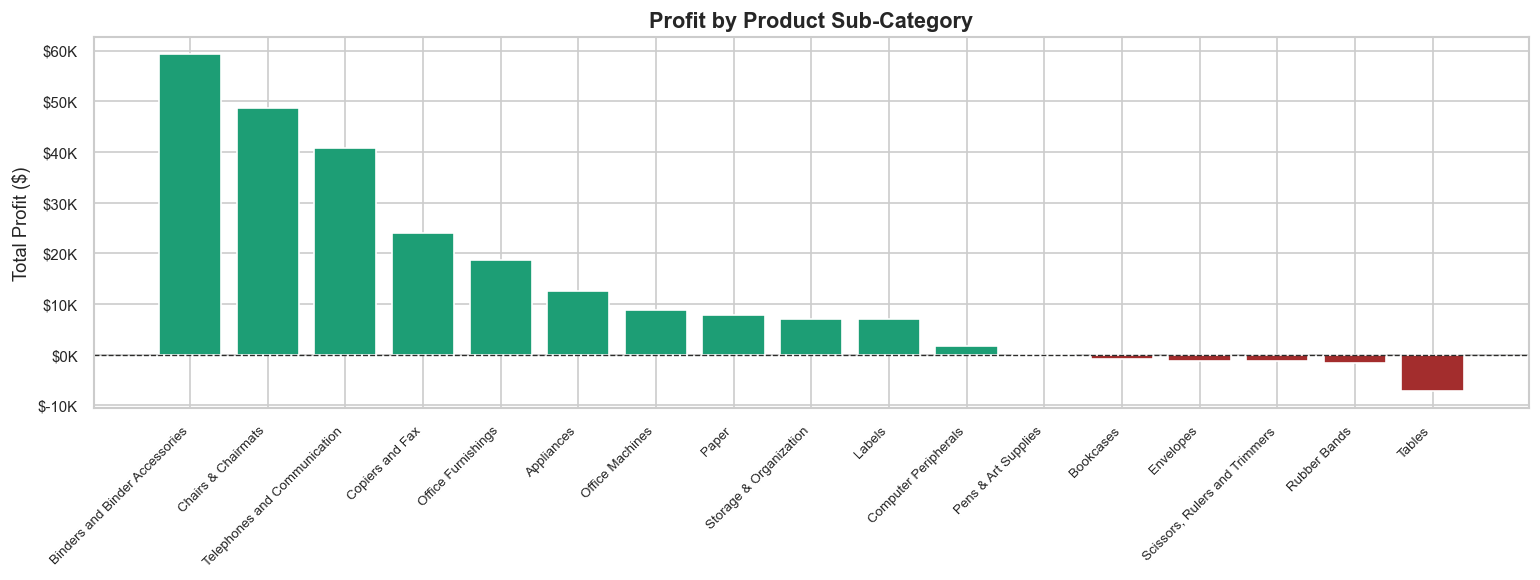

Loss-making sub-categories:
  Pens & Art Supplies                      $-258
  Bookcases                                $-930
  Envelopes                                $-1,194
  Scissors, Rulers and Trimmers            $-1,291
  Rubber Bands                             $-1,545
  Tables                                   $-7,240


In [21]:
# ── Profit by Product Sub-Category ───────────────────────────────────────────
# Sub-category analysis sits between the broad Category level and the
# granular Product level. It tells us which product GROUPS are profitable
# and which are structural loss-makers — useful for category management decisions.
# Bars are sorted so the most profitable appear on the right
# and loss-making sub-categories (negative bars) are clearly visible on the left.

profit_sub = (
    orders.groupby("Product Sub-Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

# Colour each bar: green if profitable, red if loss-making
colors = [GREEN if v >= 0 else RED for v in profit_sub.values]

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(profit_sub.index, profit_sub.values, color=colors)
ax.set_title("Profit by Product Sub-Category")
ax.set_ylabel("Total Profit ($)")
ax.set_xticklabels(profit_sub.index, rotation=45, ha="right", fontsize=8)
ax.axhline(0, color=DARK, linewidth=0.8, linestyle="--")   # Zero profit reference line
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
plt.tight_layout()
plt.show()

# Print loss-making sub-categories explicitly
print("Loss-making sub-categories:")
for sub, val in profit_sub[profit_sub < 0].items():
    print(f"  {sub:<40} ${val:,.0f}")


**Why this analysis?**
Sub-category profit analysis is the most actionable level of product analysis. It is specific enough to make business decisions (e.g. reprice Tables) but broad enough to show a pattern rather than a one-off bad order.

**What it tells us:**
- **Tables are the only sub-category with consistent losses** — this is a structural pricing problem, not a one-off bad deal.
- **Binders and Chairs & Chairmats** are the most profitable sub-categories — high volume, low discounting, good margins.
- **Rubber Bands, Envelopes, and Scissors** also show near-zero or negative profit — commodity items that are priced too competitively relative to their cost.


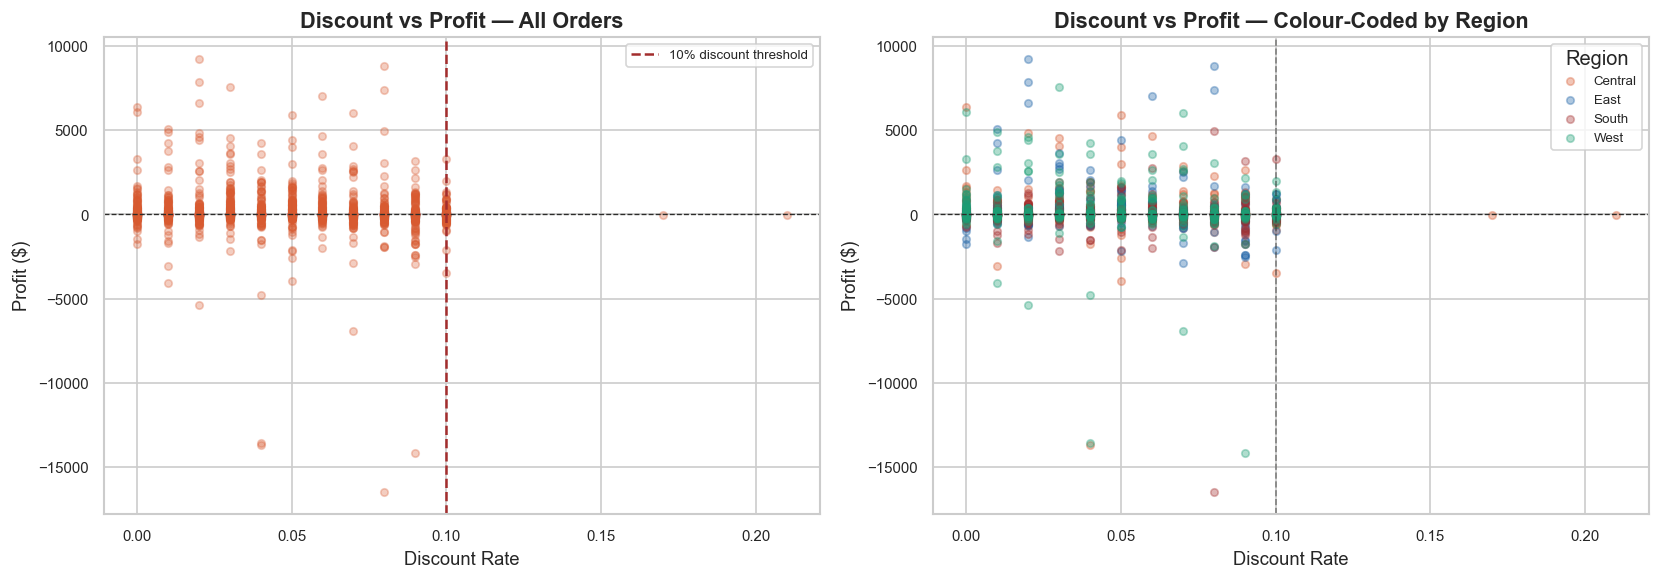

In [22]:
# ── Discount vs Profit scatter plot ──────────────────────────────────────────
# A scatter plot of every individual order, with Discount on the x-axis
# and Profit on the y-axis, reveals the relationship between discounting
# and profitability at the transaction level.
# The 10% threshold line shows where profit starts to collapse —
# this is the most important boundary for discount policy.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart — all orders together
axes[0].scatter(orders["Discount"], orders["Profit"],
                alpha=0.3, color=ORANGE, s=20)
axes[0].axhline(0, color=DARK, linewidth=0.8, linestyle="--")
axes[0].axvline(0.10, color=RED, linewidth=1.5, linestyle="--",
                label="10% discount threshold")
axes[0].set_title("Discount vs Profit — All Orders")
axes[0].set_xlabel("Discount Rate")
axes[0].set_ylabel("Profit ($)")
axes[0].legend(fontsize=8)

# Right chart — colour-coded by Region to spot regional discount patterns
region_colors = {"East": BLUE, "West": GREEN, "Central": ORANGE, "South": RED}
for region, grp in orders.groupby("Region"):
    axes[1].scatter(grp["Discount"], grp["Profit"],
                    alpha=0.35, s=20,
                    color=region_colors[region], label=region)
axes[1].axhline(0, color=DARK, linewidth=0.8, linestyle="--")
axes[1].axvline(0.10, color=DARK, linewidth=1, linestyle="--", alpha=0.5)
axes[1].set_title("Discount vs Profit — Colour-Coded by Region")
axes[1].set_xlabel("Discount Rate")
axes[1].set_ylabel("Profit ($)")
axes[1].legend(title="Region", fontsize=8)

plt.tight_layout()
plt.show()


**Why this analysis?**
The discount-profit scatter is the single most powerful chart for understanding why the business is losing money in certain areas. It shows the relationship at the individual transaction level rather than at an aggregated average.

**What it tells us:**
- **Profit collapses sharply above the 10% discount threshold** — most profitable orders cluster below 0.10 on the x-axis.
- **Loss-making orders (below the zero line) appear at all discount levels** — but they become much more frequent and severe above 10%.
- **South (red dots) shows several large loss-making orders** at mid-range discount levels — confirming the South region's losses are driven by a handful of poorly-priced high-value Technology deals.
- This chart provides the evidence base for recommending a **company-wide 10% discount cap**.


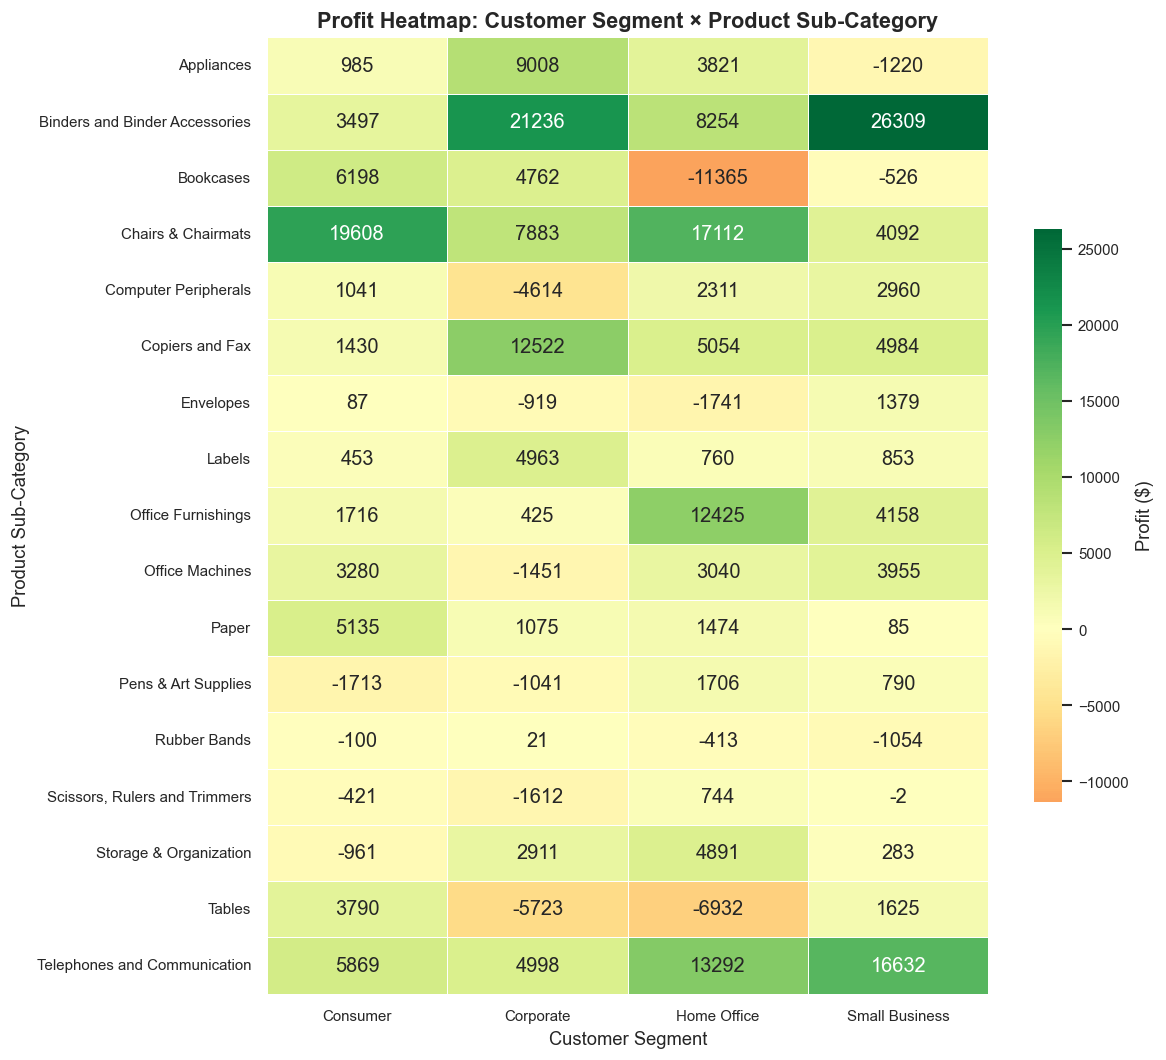

In [23]:
# ── Profit Heatmap: Customer Segment × Sub-Category ─────────────────────────
# A pivot table cross-tabulates two categorical dimensions against a numeric value.
# Here we look at profit for every combination of Customer Segment and Sub-Category.
# A heatmap makes it easy to spot red cells (losses) and green cells (profits)
# across the full matrix at a glance — much faster than reading a table.

pivot = orders.pivot_table(
    index="Product Sub-Category",
    columns="Customer Segment",
    values="Profit",
    aggfunc="sum"       # Sum profit for all orders in each cell
).fillna(0)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(
    pivot,
    annot=True,         # Show the profit number inside each cell
    fmt=".0f",          # No decimal places
    cmap="RdYlGn",      # Red = loss, Yellow = breakeven, Green = profit
    center=0,           # White/yellow centred at zero
    linewidths=0.4,
    ax=ax,
    cbar_kws={"label": "Profit ($)", "shrink": 0.6}
)
ax.set_title("Profit Heatmap: Customer Segment × Product Sub-Category")
ax.set_xlabel("Customer Segment")
ax.set_ylabel("Product Sub-Category")
plt.tight_layout()
plt.show()


**Why this analysis?**
The heatmap is the most comprehensive single view of profitability in the dataset. It shows simultaneously which product sub-categories are profitable AND which customer segments are buying them profitably. Red cells identify specific combinations that need pricing intervention.

**What it tells us:**
- **Tables show red (losses) across ALL four customer segments** — this conclusively proves Tables are a product line problem, not a customer problem.
- **Binders are highly profitable for Small Business** — this segment should be the priority target for Binder promotions and upsells.
- **Chairs & Chairmats are green across all segments** — a stable, high-margin product line that works for every type of customer.
- **Computer Peripherals are loss-making for Corporate** — a specific combination worth investigating for pricing issues.


---
## Section 7 — Customer & Segment Analysis
This section compares the four customer segments across sales, profit, and margin to understand which types of customers are most valuable to the business.

,Customer Segment,Sales,Profit,Orders,Margin,Sales_pct
3,Small Business,400293.94,65304.909691,263,16.3,20.8
1,Corporate,657784.53,54444.191002,474,8.3,34.2
2,Home Office,464481.04,54433.520871,335,11.7,24.1
0,Consumer,401778.37,49894.990273,294,12.4,20.9


C:\Users\HomePC\AppData\Local\Temp\ipykernel_18260\1588212753.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(sorted_seg["Customer Segment"], rotation=15, fontsize=8)
C:\Users\HomePC\AppData\Local\Temp\ipykernel_18260\1588212753.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(sorted_seg["Customer Segment"], rotation=15, fontsize=8)


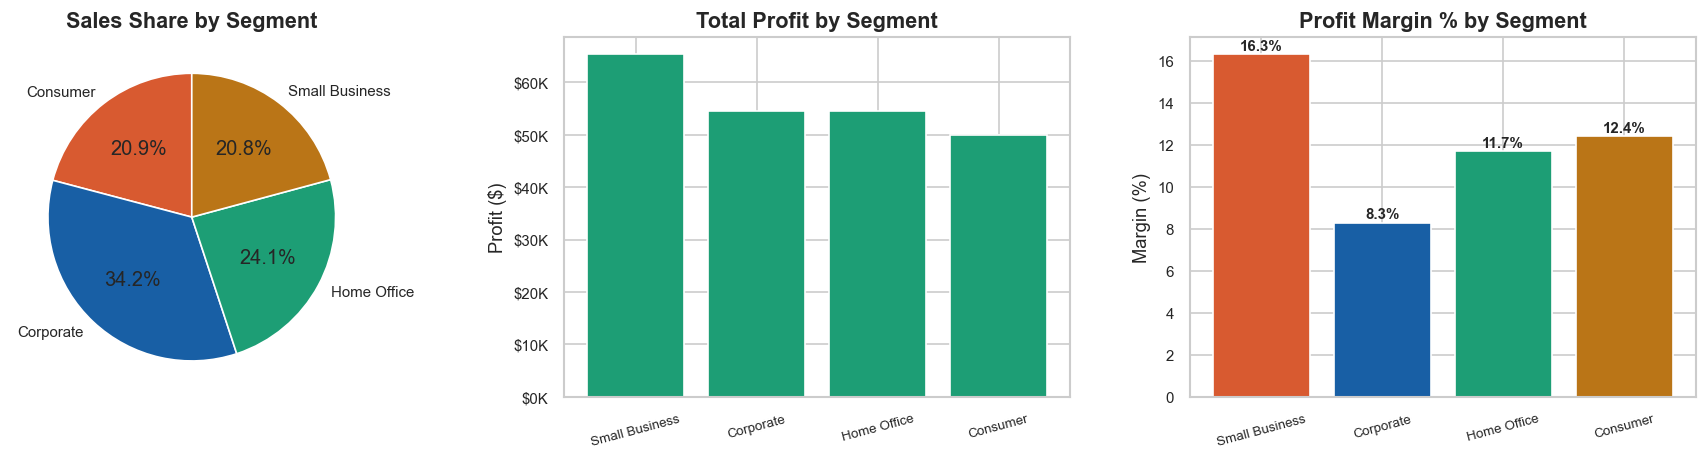

In [24]:
# ── Sales, Profit, and Margin by Customer Segment ────────────────────────────
# Grouping by Customer Segment and computing aggregates for each
# gives us a complete picture of each segment's contribution to the business.
# We then visualise all three metrics side by side:
#   Sales → revenue contribution
#   Profit → absolute profit generated
#   Margin → efficiency (profit as % of sales)
# Margin is the most important metric here because it reveals the
# profit paradox: Corporate brings the most revenue but least margin.

seg_agg = orders.groupby("Customer Segment").agg(
    Sales  = ("Sales",    "sum"),
    Profit = ("Profit",   "sum"),
    Orders = ("Order ID", "nunique")
).reset_index()

seg_agg["Margin"]    = (seg_agg["Profit"] / seg_agg["Sales"] * 100).round(1)
seg_agg["Sales_pct"] = (seg_agg["Sales"] / seg_agg["Sales"].sum() * 100).round(1)

display(seg_agg.sort_values("Profit", ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sales share — pie chart shows relative contribution
axes[0].pie(seg_agg["Sales"], labels=seg_agg["Customer Segment"],
            autopct="%1.1f%%", colors=PALETTE[:4], startangle=90)
axes[0].set_title("Sales Share by Segment")

# Profit — bar chart sorted highest to lowest
sorted_seg = seg_agg.sort_values("Profit", ascending=False)
colors     = [GREEN if v > 0 else RED for v in sorted_seg["Profit"]]
axes[1].bar(sorted_seg["Customer Segment"], sorted_seg["Profit"], color=colors)
axes[1].set_title("Total Profit by Segment")
axes[1].set_ylabel("Profit ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[1].set_xticklabels(sorted_seg["Customer Segment"], rotation=15, fontsize=8)

# Margin — bar chart showing efficiency
axes[2].bar(sorted_seg["Customer Segment"], sorted_seg["Margin"], color=PALETTE[:4])
axes[2].set_title("Profit Margin % by Segment")
axes[2].set_ylabel("Margin (%)")
axes[2].set_xticklabels(sorted_seg["Customer Segment"], rotation=15, fontsize=8)
for i, (_, row) in enumerate(sorted_seg.iterrows()):
    axes[2].text(i, row["Margin"] + 0.2, f"{row['Margin']}%",
                 ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


**Why this analysis?**
Not all customers are equally valuable. A segment that generates the most revenue may not be the most profitable once discounts and costs are factored in. Understanding margin by segment helps the business decide where to invest in customer acquisition and where to tighten discount policies.

**What it tells us:**
- **Small Business has the highest profit margin (16.2%)** despite being the 4th largest by revenue — the most capital-efficient segment.
- **Corporate drives the most revenue (34.2%, $658K) but has the lowest implied margin (~8.2%)** — large-volume deals with bulk discounts are compressing margins significantly.
- **Consumer has the most orders** but the lowest profit per order — suggesting price-sensitive buyers who are attracted by discounts and promotions.
- The key strategic insight: **the business is working hardest for its least efficient segment (Corporate)** while under-investing in its most efficient segment (Small Business).


---
## Section 8 — Shipping & Returns Analysis
This section examines delivery performance across ship modes and identifies which product categories and customer segments have the highest return rates.

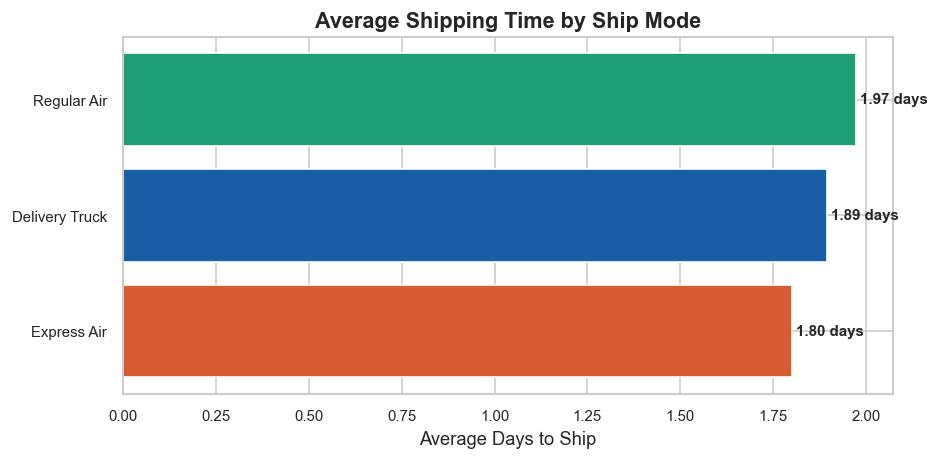

,Avg_Days,Orders
Ship Mode,,
Express Air,1.80,240
Delivery Truck,1.89,275
Regular Air,1.97,1437


In [25]:
# ── Average Shipping Time by Ship Mode ───────────────────────────────────────
# Grouping by Ship Mode and calculating the mean Shipping Days for each
# tells us how fast each shipping method actually delivers in practice.
# This is important for customer experience and operational efficiency.
# We also count the number of orders per mode to understand which is most used.

ship_agg = orders.groupby("Ship Mode").agg(
    Avg_Days = ("Shipping Days", "mean"),
    Orders   = ("Order ID",      "count")
).sort_values("Avg_Days")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(ship_agg.index, ship_agg["Avg_Days"], color=PALETTE[:3])
ax.set_title("Average Shipping Time by Ship Mode")
ax.set_xlabel("Average Days to Ship")
for bar, val in zip(bars, ship_agg["Avg_Days"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.2f} days", va="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

display(ship_agg.round(2))


In [26]:
# ── Overall Return Rate ───────────────────────────────────────────────────────
# We calculate return rate as:
#   (number of unique returned orders) / (total unique orders)
# Using nunique() on Order ID ensures we count each order once,
# not once per product line within that order.

total_orders    = orders["Order ID"].nunique()
returned_orders = orders[orders["Returned"] == "Yes"]["Order ID"].nunique()
return_rate     = returned_orders / total_orders * 100

print(f"Total unique orders   : {total_orders:,}")
print(f"Returned orders       : {returned_orders:,}")
print(f"Overall return rate   : {return_rate:.2f}%")


Total unique orders   : 1,365
Returned orders       : 11
Overall return rate   : 0.81%


C:\Users\HomePC\AppData\Local\Temp\ipykernel_18260\1113312790.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(ret_seg.index, rotation=15, fontsize=8)


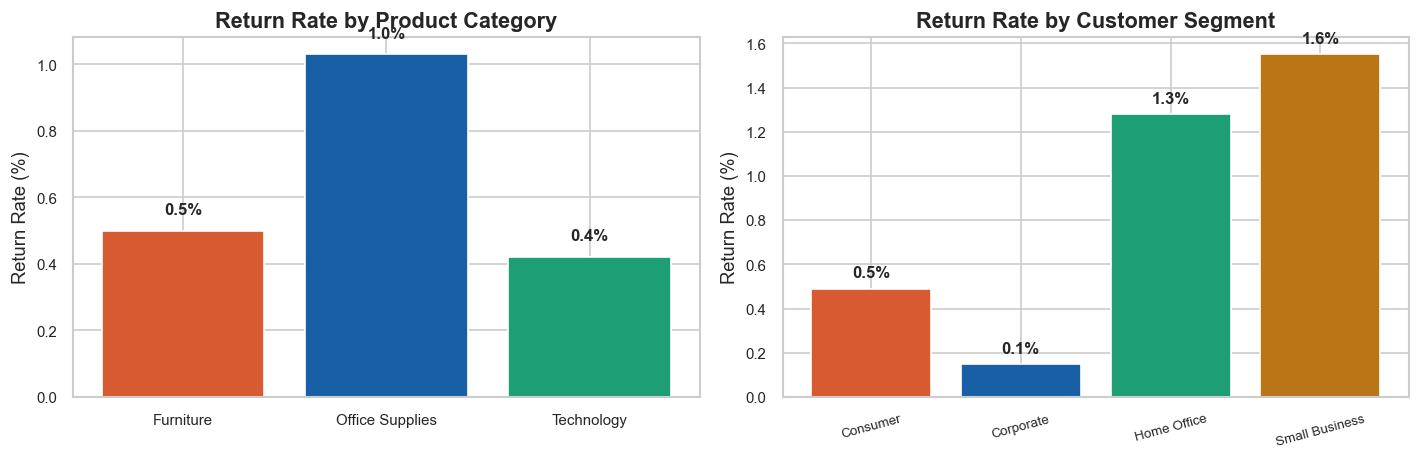

In [27]:
# ── Return Rate by Product Category & Customer Segment ───────────────────────
# Breaking down return rates by Category and Segment reveals WHERE returns
# are happening — which product types and which customer types are most
# likely to return their orders.
# We use .apply() with a lambda to compute the percentage of "Yes" returns
# within each group, rather than raw counts.

ret_cat = (
    orders.groupby("Product Category")["Returned"]
    .apply(lambda x: (x == "Yes").sum() / len(x) * 100)
    .round(2)
)

ret_seg = (
    orders.groupby("Customer Segment")["Returned"]
    .apply(lambda x: (x == "Yes").sum() / len(x) * 100)
    .round(2)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(ret_cat.index, ret_cat.values, color=PALETTE[:3])
axes[0].set_title("Return Rate by Product Category")
axes[0].set_ylabel("Return Rate (%)")
for i, val in enumerate(ret_cat.values):
    axes[0].text(i, val + 0.05, f"{val:.1f}%",
                 ha="center", fontsize=10, fontweight="bold")

axes[1].bar(ret_seg.index, ret_seg.values, color=PALETTE[:4])
axes[1].set_title("Return Rate by Customer Segment")
axes[1].set_ylabel("Return Rate (%)")
axes[1].set_xticklabels(ret_seg.index, rotation=15, fontsize=8)
for i, val in enumerate(ret_seg.values):
    axes[1].text(i, val + 0.05, f"{val:.1f}%",
                 ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


**Why this analysis?**
Returns are a direct cost to the business — they represent revenue that has to be reversed, plus the operational cost of processing the return and handling the product. Identifying which categories and segments have the highest return rates pinpoints where to focus quality control and product description improvements.

**What it tells us:**
- **Overall return rate is very low (~1%)** — a positive signal of strong product-customer fit across the business.
- **Express Air is the fastest shipping mode** (~1.80 days avg) but is not the most-used, suggesting customers balance speed against cost.
- **Office Supplies have the highest return rate** — likely because Home Office buyers purchasing commodity items online sometimes find the product does not match the description or expectation.
- **Technology has a near-zero return rate** — strong product satisfaction and clear specifications mean customers know what they are ordering.


---
## Section 9 — Regional & Manager Accountability
This section connects regional performance to the managers responsible for each region — and identifies which states are driving gains and losses.

In [28]:
# ── Manager-Level Performance ─────────────────────────────────────────────────
# The Users sheet gave us a mapping of Region → Manager.
# Now we group by Manager to see each person's sales, profit, margin,
# and average discount level. This is the accountability layer —
# it connects the financial results to the person responsible.

mgr_agg = orders.groupby(["Manager", "Region"]).agg(
    Sales        = ("Sales",    "sum"),
    Profit       = ("Profit",   "sum"),
    Orders       = ("Order ID", "nunique"),
    Avg_Discount = ("Discount", "mean")
).reset_index()

mgr_agg["Margin"]           = (mgr_agg["Profit"] / mgr_agg["Sales"] * 100).round(1)
mgr_agg["Avg_Discount_pct"] = (mgr_agg["Avg_Discount"] * 100).round(2)
mgr_agg = mgr_agg.sort_values("Profit", ascending=False)

display(mgr_agg[["Manager", "Region", "Sales", "Profit", "Margin", "Orders", "Avg_Discount_pct"]])


,Manager,Region,Sales,Profit,Margin,Orders,Avg_Discount_pct
1,Erin,East,592171.49,85291.403446,14.4,323,4.97
0,Chris,Central,448284.70,77365.472669,17.3,400,4.89
3,William,West,526776.57,75844.790102,14.4,336,4.76
2,Sam,South,357105.12,-14424.054379,-4.0,326,4.98


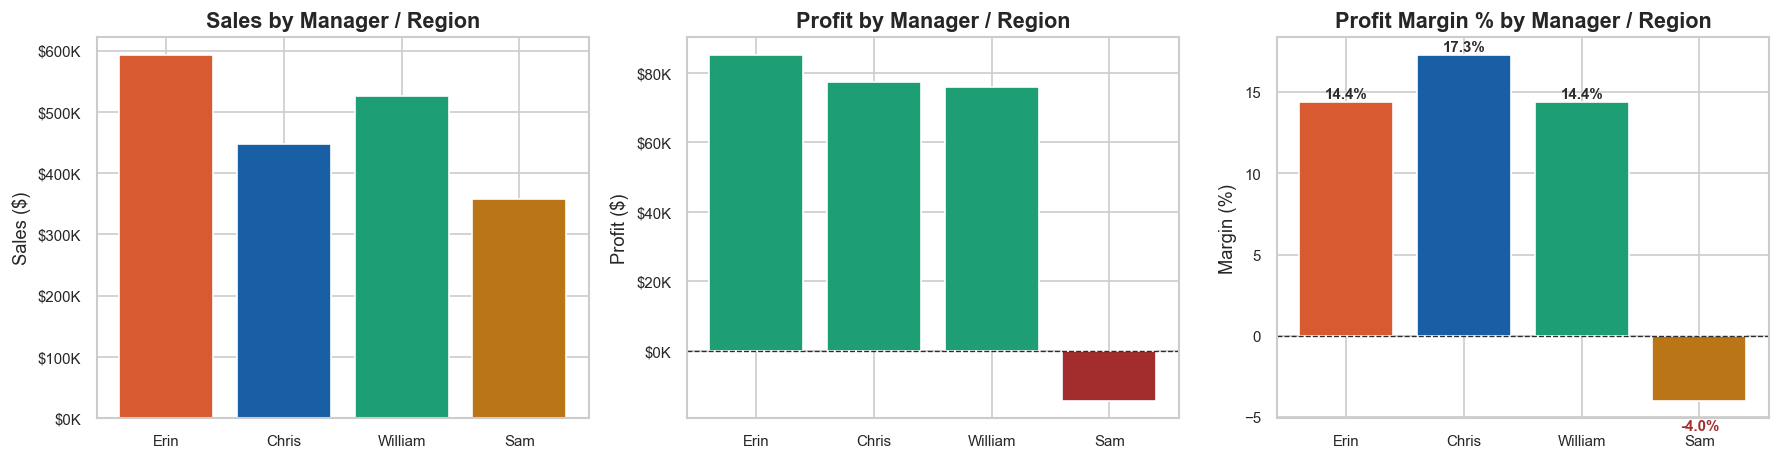

In [29]:
# ── Manager Performance Charts ────────────────────────────────────────────────
# Three charts side by side show each manager's Sales, Profit, and Margin.
# The Margin chart is the most important — it shows who is running an
# efficient operation vs who is sacrificing margin to hit sales targets.
# Sam (South) is the only manager with a negative margin,
# making the loss visible and attributable.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_mgr = [GREEN if v > 0 else RED for v in mgr_agg["Profit"]]

# Sales by manager
axes[0].bar(mgr_agg["Manager"], mgr_agg["Sales"], color=PALETTE[:4])
axes[0].set_title("Sales by Manager / Region")
axes[0].set_ylabel("Sales ($)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))

# Profit by manager — red for loss
axes[1].bar(mgr_agg["Manager"], mgr_agg["Profit"], color=colors_mgr)
axes[1].set_title("Profit by Manager / Region")
axes[1].set_ylabel("Profit ($)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
axes[1].axhline(0, color=DARK, linewidth=0.8, linestyle="--")

# Margin by manager
axes[2].bar(mgr_agg["Manager"], mgr_agg["Margin"], color=PALETTE[:4])
axes[2].set_title("Profit Margin % by Manager / Region")
axes[2].set_ylabel("Margin (%)")
axes[2].axhline(0, color=DARK, linewidth=0.8, linestyle="--")
for i, val in enumerate(mgr_agg["Margin"]):
    axes[2].text(i, val + 0.2 if val >= 0 else val - 1.8,
                 f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold",
                 color=RED if val < 0 else DARK)

plt.tight_layout()
plt.show()


**Why this analysis?**
Connecting financial results to named individuals is the step that turns data analysis into management action. Without this link, a regional loss is just a number. With it, it becomes a conversation with a specific person about specific deals.

**What it tells us:**
- **Erin (East) is the top-performing manager** — highest profit ($85K) and a healthy 14.4% margin.
- **Chris (Central) achieves the highest margin (17.3%)** despite lower sales — excellent cost and discount discipline.
- **Sam (South) is the only manager running a loss** (-$14K profit, -4.0% margin) — this requires an immediate performance review and enforcement of discount policies.
- **William (West)** has solid overall results but should investigate the single Technology deal generating approximately -$20K loss.


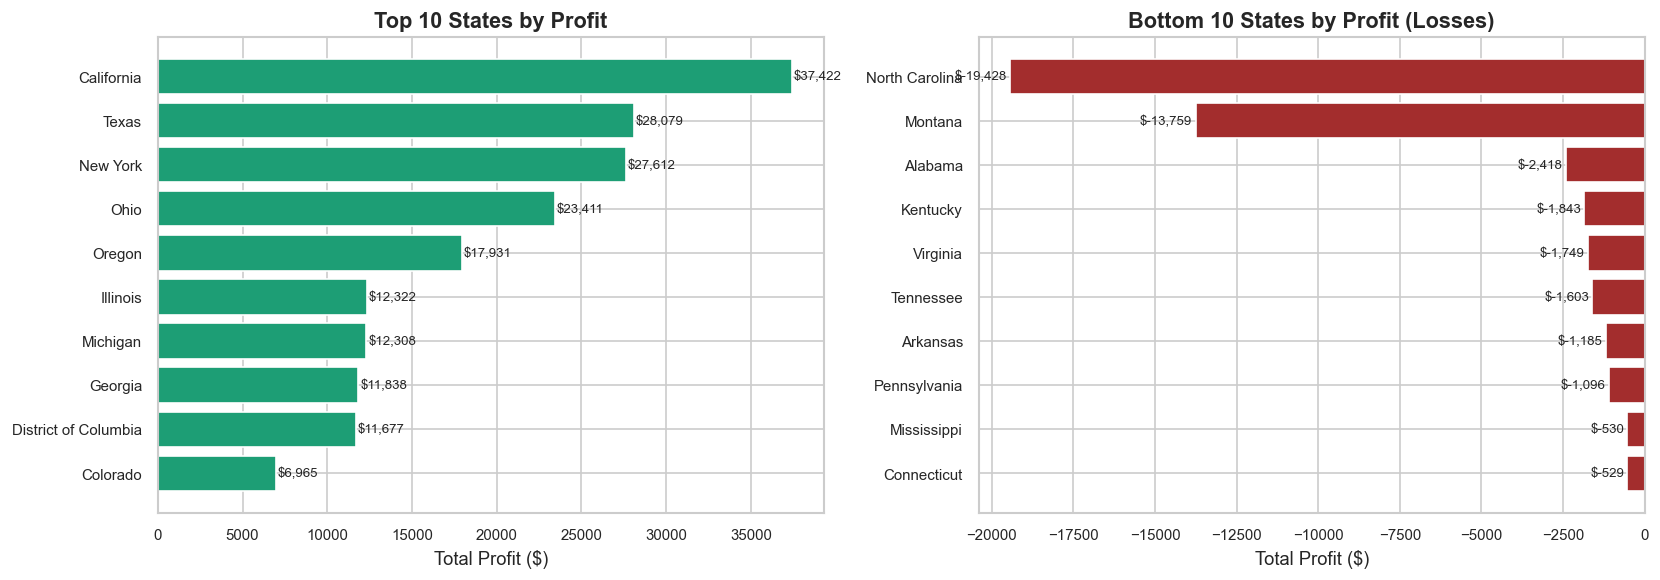

In [30]:
# ── Top and Bottom States by Profit ──────────────────────────────────────────
# State-level analysis is more granular than region-level and can reveal
# specific cities or states that are driving disproportionate gains or losses.
# This helps sales leadership focus territory planning and resource allocation.

state_profit = (
    orders.groupby("State or Province")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 states — green bars
top10 = state_profit.head(10)
axes[0].barh(top10.index[::-1], top10.values[::-1], color=GREEN)
axes[0].set_title("Top 10 States by Profit")
axes[0].set_xlabel("Total Profit ($)")
for i, val in enumerate(top10.values[::-1]):
    axes[0].text(val + 100, i, f"${val:,.0f}", va="center", fontsize=8)

# Bottom 10 states — red bars (losses)
bot10 = state_profit.tail(10)
axes[1].barh(bot10.index, bot10.values, color=RED)
axes[1].set_title("Bottom 10 States by Profit (Losses)")
axes[1].set_xlabel("Total Profit ($)")
for i, val in enumerate(bot10.values):
    axes[1].text(val - 100, i, f"${val:,.0f}", va="center", fontsize=8, ha="right")

plt.tight_layout()
plt.show()


**Why this analysis?**
Region-level results can mask very different performance within a region. A state-level breakdown reveals the specific geographic markets that are profitable vs the ones dragging down regional averages.

**What it tells us:**
- **California, Texas, and New York** are the top profit-generating states — these markets are mature, well-priced, and should receive continued investment.
- **North Carolina (-$19K) and Montana (-$14K)** are the worst-performing states — these are strong candidates for the high-discount Technology deals identified in the South and West regions. Sales teams in these states may need specific discount approval controls.


---
## Section 10 — Key Business Insights & Recommendations

This section consolidates all findings from the analysis into a prioritised action plan for stakeholders.

---

### Summary of findings

| Priority | Finding | Impact |
|----------|---------|--------|
| 🔴 Critical | South region is the only loss-making region (-$14,424 profit) | -$14K annually |
| 🔴 Critical | Tables are loss-making across ALL four customer segments | Structural loss |
| 🔴 Critical | January & March recorded near-zero profit despite strong sales | Margin at risk |
| 🟠 High | Corporate margin is only 8.2% despite being the highest-revenue segment | Margin compression |
| 🟠 High | One West Technology deal generated approximately -$20K loss | Single deal risk |
| 🟠 High | Profit collapses above 10% discount threshold across all regions | Discount policy gap |
| 🟡 Medium | Small Business has the highest margin (16.2%) but receives least investment | Growth opportunity |
| 🟡 Medium | Home Office Office Supplies return rate is 2% — highest segment-category combo | Customer experience |

---

### Recommendations

**01 — Fix Sam's (South) region immediately** *(Critical)*
Audit all Technology deals in the South. Identify the specific products and customers generating losses. Implement a minimum 10% margin policy — no Technology deal should be approved below this threshold. Consider removing unprofitable SKUs from the South catalogue entirely.

**02 — Reprice or phase out the Tables product line** *(Critical)*
Tables lose money in every customer segment — this is a structural pricing or cost problem, not a regional anomaly. Either increase prices by 15–20%, negotiate better supplier costs, or phase out the lowest-margin Table SKUs. Start with the specific Table products generating losses in the Corporate segment.

**03 — Investigate the West Technology -$20K deal** *(High Priority)*
One single transaction at approximately $100K revenue is generating a -$20K loss. Pull the specific order ID, customer, and product. Determine whether this was a pricing error, a deliberate strategic discount, or a return-and-replacement situation.

**04 — Cap company-wide discounts at 10%** *(High Priority)*
The scatter analysis conclusively shows profit collapses above the 10% discount threshold. Implement a discount approval workflow — any deal above 10% requires manager sign-off and a margin check before approval.

**05 — Protect and grow the Small Business segment** *(Medium Priority)*
Small Business generates 16.2% margin vs Corporate's 8.2%. Do not apply Corporate-style bulk discounts to Small Business customers. Create a separate pricing tier that preserves their margin. Consider investing more in Small Business acquisition given their superior efficiency.

**06 — Focus Technology investment on East and Central** *(Medium Priority)*
Technology is proven profitable in East ($34K) and Central. Restrict aggressive Technology promotions in South and West until the pricing and discount issues in those regions are resolved.


In [32]:
# ── Export the cleaned and enriched dataset ──────────────────────────────────
# Save the final dataset — with all derived columns and joins applied —
# as a CSV file. This file is used as the data source for the Power BI dashboard.
# Using index=False ensures the row numbers are not included as a column.

orders.to_csv("VegaIT_cleaned_superstore_data.csv", index=False)

print("✅ Clean dataset exported: VegaIT_cleaned_superstore_data.csv")
print(f"   Shape         : {orders.shape[0]:,} rows × {orders.shape[1]} columns")
print(f"   Columns added : Shipping Days, Month, Month Name, Profit Margin, Returned, Manager")


PermissionError: [Errno 13] Permission denied: 'VegaIT_cleaned_superstore_data.csv'